# Projeto de Detecção de Fraudes em Transações Cartões de Crédito
## Sobre
O intuito desse projeto será de, utilizando um dataset que traz diversas features anonimizadas sobre transações ocorridas em Setembro de 2013, tentar descobrir padrões de fraudes e saber quais modelos e parâmetros irão trazer um maior aproveitamento na detecção de possíveis novas fraudes.
## Créditos
O dataset pode ser encontrado no link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data. Ele, que por sua vez, foi coletado e analizado por pesquisadores da Worldline e do Machine Learning Group da ULB (Université Libre de Bruxelles).

## Análise Exploratória de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [4]:
df.shape

(284807, 31)

In [5]:
df_PrimeirasLinhas = df.head(1000)

In [6]:
df_PrimeirasLinhas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   float64
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   V6      1000 non-null   float64
 7   V7      1000 non-null   float64
 8   V8      1000 non-null   float64
 9   V9      1000 non-null   float64
 10  V10     1000 non-null   float64
 11  V11     1000 non-null   float64
 12  V12     1000 non-null   float64
 13  V13     1000 non-null   float64
 14  V14     1000 non-null   float64
 15  V15     1000 non-null   float64
 16  V16     1000 non-null   float64
 17  V17     1000 non-null   float64
 18  V18     1000 non-null   float64
 19  V19     1000 non-null   float64
 20  V20     1000 non-null   float64
 21  V21     1000 non-null   float64
 22  V

In [7]:
df_PrimeirasLinhas.isnull().sum() #Não possui valores nulos!

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### Análise dos nomes das colunas
O primeiro desafio desse projeto será compreender um pouco as features que temos. O principal problema é que, por conta da anonimização feita, temos apenas reduções feitas por PCA, sem muito contexto, indo de V1 a V28. As únicas que possuem algum nome são: "Time" que é o tempo decorrido entre a primeira transação do dataset e a da linha, "Amount" que é o valor, e "Class", que se for 1, houve de fato uma fraude, 0 caso contrário.

### Proporção fraude - legítimo
Um dos pontos essenciais desse dataset, é a sua quantidade massiva de transações legítimas em relação à fraudes. Isso é percebido logo no describe acima, onde a média da classe é 0.002 para 1000 amostras. Isso significa que nas 1000 primeiras linhas, apenas 2 foram consideradas fraude! Então, irei mostrar as correlações com esses números brutos para "Class", e depois irei tentar melhorar um pouco essa distribuição para podermos identificar alguns padrões.

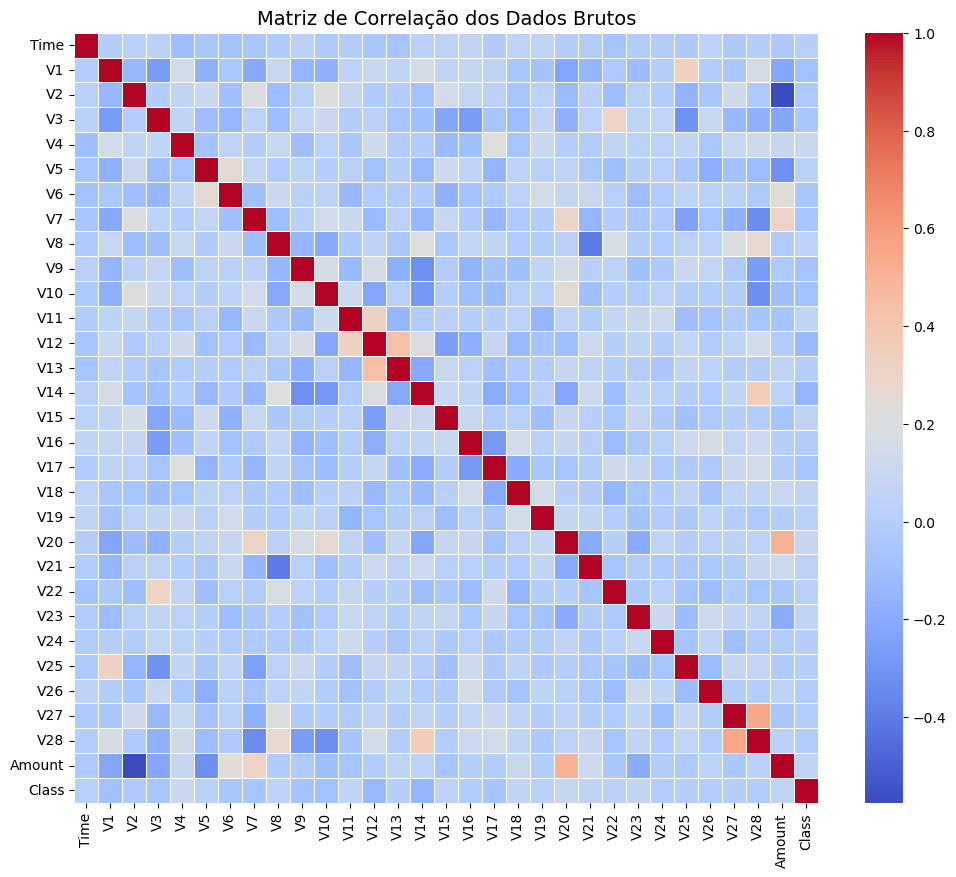

In [9]:
corr = df_PrimeirasLinhas.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=.5, ax=ax)
ax.set_title("Matriz de Correlação dos Dados Brutos", fontsize=14)
plt.show()

O meu objetivo agora será pegar o dataframe original e criar uma divisão 50/50 entre transações legítimas e fraudulentas. Dessa maneira, irei ser capaz de analisar nossas features de uma melhor maneira.

In [10]:
df_fraudes = df[df["Class"] == 1]
df_legitimas = df[df["Class"] == 0]

In [11]:
df_fraudes.shape #Verificando que realmente temos 492 fraudes, como descrito no site original do dataset

(492, 31)

In [12]:
amostra_legitimas = df_legitimas.sample(n=len(df_fraudes), random_state=42)
df_balanceado = pd.concat([df_fraudes, amostra_legitimas])
df_balanceado = df_balanceado.sample(frac=1, random_state=42)

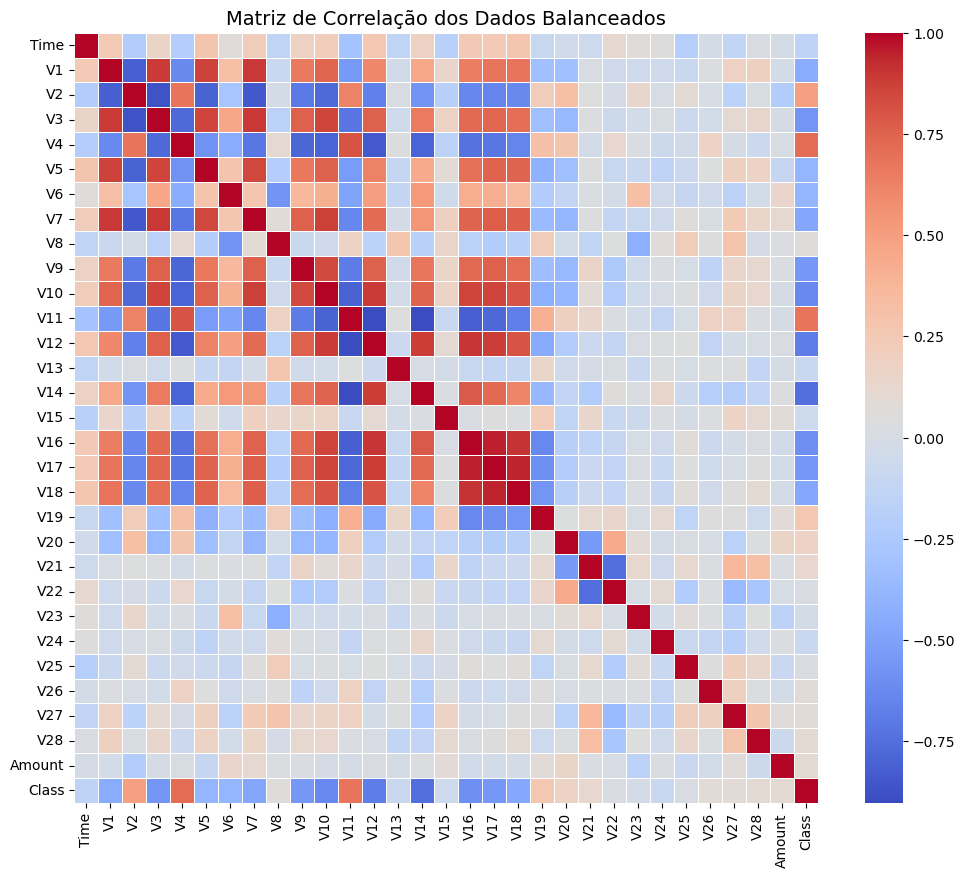

In [13]:
corr = df_balanceado.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f', linewidths=.5, ax=ax)
ax.set_title("Matriz de Correlação dos Dados Balanceados", fontsize=14)
plt.show()

### Análise inicial da nova correlação
Agora, como podemos observas, após o balanceamento, é perceptível uma maior correlação da Class com as features V2, V4 e V11 (sejam elas quais forem) e uma correlação negativa com V10, V12 e V14.

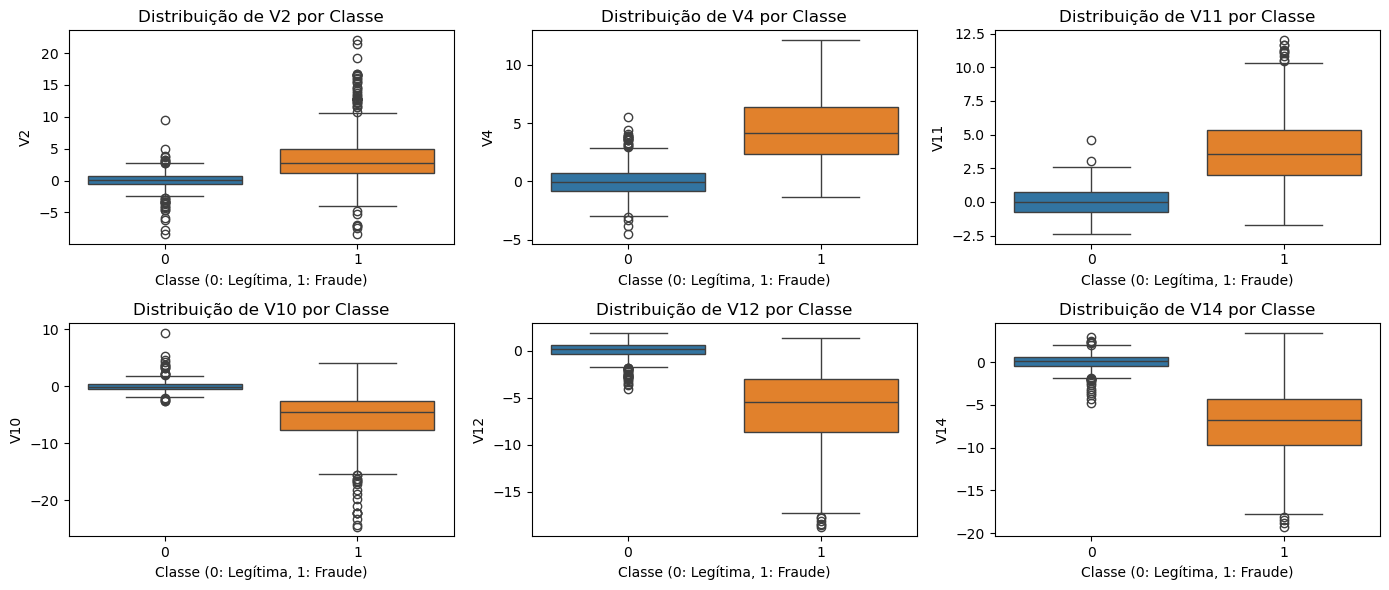

In [14]:
features_importantes = ["V2", "V4", "V11", "V10", "V12", "V14"] #Colunas com caracteristicas mais importantes da análise

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes_flat = axes.flatten()

for i, col in enumerate(features_importantes):
    sns.boxplot(x="Class", y=col, data=df_balanceado, ax=axes_flat[i], hue="Class", legend=False)
    axes_flat[i].set_title(f"Distribuição de {col} por Classe")
    axes_flat[i].set_xlabel("Classe (0: Legítima, 1: Fraude)")
    axes_flat[i].set_ylabel(col)

plt.tight_layout()
plt.show()

Analisando os boxplots, podemos ver que essas colunas ditas como "importantes" anteriormente, são de fato de nosso interesse, já que os valores de quando a transação é fraudulenta ou legítima não são compartilhados, em geral. Dessa maneira, mais adiante será possível utilizar desse fato para treinar diferentes modelos. 

## Separação das Amostras
Agora, começarei a modificar o meu dataset original para que possa ser usado nos modelos futuros. Começando, irei dividí-lo em 60% treinamento, 20% validação e 20% teste.

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
X = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.245, random_state=42, stratify=y_train)

# Mostrando a distribuição das fraudes dentro de cada vetor y
print((y_train).sum())
print((y_val).sum())
print((y_test).sum())

297
97
98


Como o tempo e a quantia possuem uma grande variância, tendo inclusive diversos outliers, principalmente para o valor, irei utilizar o RobustScaler, que é mais adequado para essa situação.

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])

X_val[['Time', 'Amount']] = scaler.transform(X_val[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
19630,-0.639193,-12.504075,6.883019,-12.780784,2.165750,-7.333516,-1.977502,-5.124778,8.358733,0.252685,...,0.034412,-0.061229,-1.338435,-0.590958,-0.734823,0.529236,-0.305706,-0.164715,-0.346552,0.950909
30283,-0.575366,-0.332571,1.423806,0.307064,0.045943,0.044616,0.166480,-0.730333,-3.307725,-0.102092,...,-0.585147,2.697858,-2.084297,0.218027,-0.522302,1.036559,0.240684,0.133125,0.130713,-0.280000
239914,0.770301,1.815660,-1.947800,-3.033987,-1.609436,-0.100827,-0.707441,0.311438,-0.521789,-2.389390,...,0.184489,0.320595,0.737850,-0.439702,0.295867,0.579074,0.249269,-0.132467,-0.043923,4.083916
31676,-0.568184,0.623798,-0.836673,0.692871,1.393657,-0.560068,1.087063,-0.317520,0.397545,0.592863,...,0.222535,0.193205,0.404943,-0.253634,-0.239246,0.417186,-0.257742,0.046905,0.047662,2.809790
145970,0.029562,-3.868050,4.079832,-2.079816,-1.588236,-0.126823,-1.038527,0.777707,0.079872,3.189983,...,2.359097,-0.116325,0.981916,0.049544,-0.379303,0.141354,-0.139177,2.381101,1.395565,-0.295245


## Teste de Modelo de Regressão Logística
Como a característica da minha Classe é ser 1 ou 0, acredito ser uma boa tentativa de usar um modelo de regressão logística para esse caso. Assim, irei primeiro analisar como ficam as métricas com o dataframe desbalanceado e usando todas as features que temos.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model_lr = LogisticRegression(max_iter=1000, random_state=42)

In [20]:
model_lr.fit(X_train, y_train)
y_lr_pred = model_lr.predict(X_val)

In [21]:
def printScores(y_val, y_pred, y_pred_prob=None):
    print("Matriz de Confusão")
    print(confusion_matrix(y_val, y_pred))

    print("Relatório de Classificação")
    print(classification_report(y_val, y_pred))

    if y_pred_prob is not None:
        print("ROC AUC Score")
        print(roc_auc_score(y_val, y_pred_prob))

In [22]:
y_pred_prob = model_lr.predict_proba(X_val)[:, 1]
printScores(y_val, y_lr_pred, y_pred_prob=y_pred_prob)

Matriz de Confusão
[[55716    10]
 [   47    50]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55726
           1       0.83      0.52      0.64        97

    accuracy                           1.00     55823
   macro avg       0.92      0.76      0.82     55823
weighted avg       1.00      1.00      1.00     55823

ROC AUC Score
0.9657029552919273


Apesar do ROC AUC Score e da precisão no f1-score nos dizer que o modelo está excelente, a matriz de confusão e o recall de 1 diz que ainda possuem muitas fraudes que não estão sendo detectadas. Assim, partirei para outras duas tentativas. irei balancear as amostras primeiro por under-sampling e depois por um tipo de SMOTE.

## Tentativa com Under-sampling

In [23]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print(f"{len(y_train_us)} amostras, sendo {y_train_us.sum()} fraudes")

594 amostras, sendo 297 fraudes


In [24]:
model_lr_us = LogisticRegression(max_iter=1000, random_state=42)
model_lr_us.fit(X_train_us, y_train_us)
y_lr_us_pred = model_lr_us.predict(X_val) #Utilizando um dataframe desbalanceado para imitar uma situação real

y_us_pred_prob = model_lr_us.predict_proba(X_val)[:, 1]
printScores(y_val, y_lr_us_pred, y_pred_prob=y_us_pred_prob)

Matriz de Confusão
[[54093  1633]
 [   12    85]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     55726
           1       0.05      0.88      0.09        97

    accuracy                           0.97     55823
   macro avg       0.52      0.92      0.54     55823
weighted avg       1.00      0.97      0.98     55823

ROC AUC Score
0.9617132575402993


Como podemos observar, o recall para fraudes foi drasticamente melhorado, mostrando que esse modelo consegue detectar mais fraudes em relação ao anterior. O problema é que, por conta do tipo de balanceamento usado, ele acusa mais vezes as transações legítimas de algo errado, por isso, a queda da precisão. Em seguida, irei usar a técnica de over-sampling SMOTE, junto com o Tomek Links, para uma limpeza desses dados gerados artificialmente.

## Tentativa com Over-sampling

In [25]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print(f"{len(y_train_smt)} amostras, sendo {y_train_smt.sum()} fraudes")

343450 amostras, sendo 171725 fraudes


In [26]:
model_lr_smt = LogisticRegression(random_state=42)
model_lr_smt.fit(X_train_smt, y_train_smt)
y_lr_smt_pred = model_lr_smt.predict(X_val)

y_smt_pred_prob = model_lr_smt.predict_proba(X_val)[:, 1]
printScores(y_val, y_lr_smt_pred, y_pred_prob=y_smt_pred_prob)

Matriz de Confusão
[[54392  1334]
 [   12    85]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     55726
           1       0.06      0.88      0.11        97

    accuracy                           0.98     55823
   macro avg       0.53      0.93      0.55     55823
weighted avg       1.00      0.98      0.99     55823

ROC AUC Score
0.9707058949329026


### Comparação Under-sampling x Over-sampling
Após feito os dois modelos, podemos tirar algumas conclusões. Primeiramente, comparado ao modelo com os dados não balanceados, ambos tiveram um aumento suave no ROC AUC Score e um acréscimo considerável no recall, sendo o preço a se pagar a precisão. Fazendo uma análise da performance do under contra o over-sampling, vemos que o segundo tipo foi capaz de, com a mesma capacidade de detectar fraudes reais, dar menos falsos positivos. Com isso, entre essas 3 opções utilizando o modelo de regressão logística, acredito que o mais seguro e ao mesmo tempo relativamente amigável ao usuário do cartão (por conta da quantidade ainda considerável de falsos positivos), seria o terceiro (Over-sampling com SMOTE e Tomek).

## Teste com Random Forest
Anteriormente, testei alguns modelos que se baseiam em uma relação linear. Porém, sabemos o quão complexo é uma transação. Ela pode ser legítima mesmo com valores extremamente altos e pode ser fraudulenta com valores baixos, e são esses casos que farão com que eu teste agora as árvores de decisão, sendo mais específico, usarei diversas delas em conjunto para obter um melhor resultado.

In [27]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

In [29]:
model_rf.fit(X_train, y_train)

y_rf_pred = model_rf.predict(X_val)
y_rf_pred_prob = model_rf.predict_proba(X_val)[:, 1]
printScores(y_val, y_rf_pred, y_pred_prob=y_rf_pred_prob)

Matriz de Confusão
[[55716    10]
 [   27    70]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55726
           1       0.88      0.72      0.79        97

    accuracy                           1.00     55823
   macro avg       0.94      0.86      0.90     55823
weighted avg       1.00      1.00      1.00     55823

ROC AUC Score
0.9689389653573763


Nesse primeiro teste, decidi por utilizar parâmetros iniciais que intuitivamente pareciam que seriam decentes para o caso. Dessa maneira, podemos observar que, a partir da matriz de confusão, em relação aos modelos lineares utilizados, a quantidade de falsos positivos caiu drasticamente, ao custo de classificarmos de não detectarmos algumas fraudes. Um dos parâmetros que fez ser possível chegar a um resultado desse nível foi dar um "class weight" balanceado à nossa entrada, pois temos um número bem menor de fraudes nesse conjunto de treinamento, assim, devemos dar mais peso ao classificar uma fraude como legítima.

### Ajuste de hiperparâmetros
Como acredito que as random forests serão o caminho da solução desse problema, irei iterar sobre alguns diferentes parâmetros e analisar quais devem ser o ideal para se utilizar nesse modelo.

In [30]:
estimators_list = [50, 100, 150]
depth_list = [10, 15, 20]
weight_list = ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

result = []

for estimator in estimators_list:
    for depth in depth_list:
        for weight in weight_list:
            model = RandomForestClassifier(
                n_estimators=estimator,
                max_depth=depth,
                class_weight=weight,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            
            prec = precision_score(y_val, y_pred)
            rec = recall_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred)

            result.append({
                'n_estimators': estimator,
                'max_depth': depth,
                'class_weight': str(weight),
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })

            print(f"Terminado o teste para estimadores: {estimator}, profundidade: {depth}, peso: {weight}")

Terminado o teste para estimadores: 50, profundidade: 10, peso: balanced
Terminado o teste para estimadores: 50, profundidade: 10, peso: {0: 1, 1: 5}
Terminado o teste para estimadores: 50, profundidade: 10, peso: {0: 1, 1: 10}
Terminado o teste para estimadores: 50, profundidade: 15, peso: balanced
Terminado o teste para estimadores: 50, profundidade: 15, peso: {0: 1, 1: 5}
Terminado o teste para estimadores: 50, profundidade: 15, peso: {0: 1, 1: 10}
Terminado o teste para estimadores: 50, profundidade: 20, peso: balanced
Terminado o teste para estimadores: 50, profundidade: 20, peso: {0: 1, 1: 5}
Terminado o teste para estimadores: 50, profundidade: 20, peso: {0: 1, 1: 10}
Terminado o teste para estimadores: 100, profundidade: 10, peso: balanced
Terminado o teste para estimadores: 100, profundidade: 10, peso: {0: 1, 1: 5}
Terminado o teste para estimadores: 100, profundidade: 10, peso: {0: 1, 1: 10}
Terminado o teste para estimadores: 100, profundidade: 15, peso: balanced
Terminado o

In [34]:
df_resultados = pd.DataFrame(result)
df_resultados = df_resultados.sort_values(by='F1-Score', ascending=False)

df_resultados

,n_estimators,max_depth,class_weight,Precision,Recall,F1-Score
26,150,20,"{0: 1, 1: 10}",0.958333,0.711340,0.816568
8,50,20,"{0: 1, 1: 10}",0.958333,0.711340,0.816568
23,150,15,"{0: 1, 1: 10}",0.958333,0.711340,0.816568
17,100,20,"{0: 1, 1: 10}",0.958333,0.711340,0.816568
22,150,15,"{0: 1, 1: 5}",0.945205,0.711340,0.811765
25,150,20,"{0: 1, 1: 5}",0.944444,0.701031,0.804734
16,100,20,"{0: 1, 1: 5}",0.944444,0.701031,0.804734
13,100,15,"{0: 1, 1: 5}",0.944444,0.701031,0.804734
10,100,10,"{0: 1, 1: 5}",0.931507,0.701031,0.800000
11,100,10,"{0: 1, 1: 10}",0.931507,0.701031,0.800000


In [37]:
model_rf_best = RandomForestClassifier(n_estimators=150,
                                       max_depth=20,
                                       class_weight={0: 1, 1: 10},
                                       random_state=42,
                                       n_jobs=-1
                                      )

model_rf_best.fit(X_train, y_train)

y_pred = model_rf_best.predict(X_test)
y_bestrf_pred_prob = model_rf_best.predict_proba(X_test)[:, 1]

printScores(y_test, y_pred, y_pred_prob=y_bestrf_pred_prob)

Matriz de Confusão
[[56861     3]
 [   24    74]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score
0.9578832201141573


Utilizando o modelo com maior F1-score no conjunto de validação, conseguimos achar um resultado muito satistório em relação aos falso positivos, apenas 3 de quase 57 mil! Ainda com uma porcentagem grande de fraudes passando livremente, mas definitivamente melhor que a primeira regressão logística que fizemos. Se o objetivo for minimizar a quantidade de atendimentos para libera transações legítimas, esse modelo será uma ótima opção.

## Possíveis melhorias
Como o meu principal objetivo com este notebook era aprender e demonstrar conceitos fundamentais de Machine Learning, o projeto certamente ainda possui margem para evoluções. Entre os pontos que poderiam ser explorados em etapas futuras, destacam-se:

Utilização de algoritmos de Gradient Boosting: Testar modelos de ponta baseados em boosting, como o XGBoost, LightGBM ou CatBoost, que costumam superar as Random Forests em performance e velocidade.

Validação Cruzada robusta: Substituir a busca manual por parâmetros (o loop for) pelo GridSearchCV do Scikit-Learn, aplicando validação cruzada para garantir que a escolha dos hiperparâmetros seja estatisticamente sólida e livre de viés de partição.

Feature Engineering Avançada: Criar novas variáveis (como taxas de transação por intervalo de tempo ou desvios em relação ao perfil de consumo do cliente) para dar ainda mais poder preditivo aos modelos.

## Conclusão
Dessa forma, finalizo este projeto recapitulando a jornada de desenvolvimento e os resultados obtidos:

Análise Exploratória de Dados (EDA): Identificamos as nuances do dataset, incluindo seis variáveis com forte correlação em valor absoluto. Contudo, o fator mais determinante foi a detecção da extrema desproporção entre as classes (apenas ~0,17% de fraudes), característica que moldou todas as decisões estratégicas do projeto.

Estratégia de Modelagem: Dividimos os dados de forma consistente em conjuntos de Treino, Validação e Teste (proporção 60/20/20), aplicando o devido escalonamento (scaling) nos atributos necessários.

Evolução dos Modelos:

Regressão Logística Base: Sem qualquer tratamento para o desbalanceamento, apresentou um comportamento próximo ao aleatório para a classe de fraude (Recall baixíssimo, semelhante a um "cara ou coroa"), mostrando-se inviável para o negócio.

Regressão Logística com Amostragem (Under/Over-sampling): A aplicação de técnicas de balanceamento (como SMOTE + Tomek) trouxe ótimos resultados na captura de fraudes (Recall alto), mas ao custo de um volume elevado de falsos positivos (bloqueios indevidos de clientes).

Random Forest Otimizada: Ao mudarmos de paradigma para modelos de ensemble baseados em árvores e realizarmos o ajuste fino de hiperparâmetros, alcançamos o melhor equilíbrio. O modelo final quase anulou os falsos positivos no conjunto de teste (apenas 3 transações legítimas bloqueadas), mantendo uma taxa de captura de fraudes altamente competitiva e segura para a operação.